In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [52]:
data = pd.read_csv(r"C:\Users\ASUS\OneDrive\Dokumen\advertising.csv")

In [53]:
data = data.drop(columns=['Unnamed: 0'], errors='ignore')

In [54]:
print("Dataset Loaded Successfully!\n")
print(data.head())

Dataset Loaded Successfully!

      TV  radio  newspaper  sales
0  230.1   37.8       69.2   21.1
1   44.5   39.3       45.1   11.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


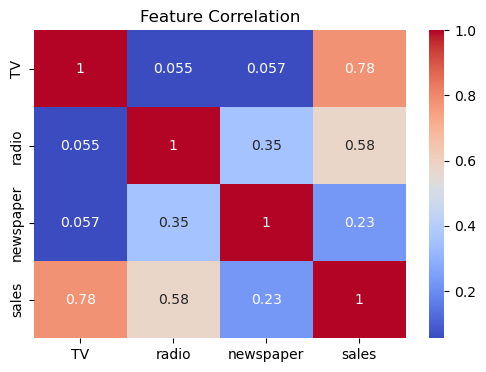

In [55]:
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

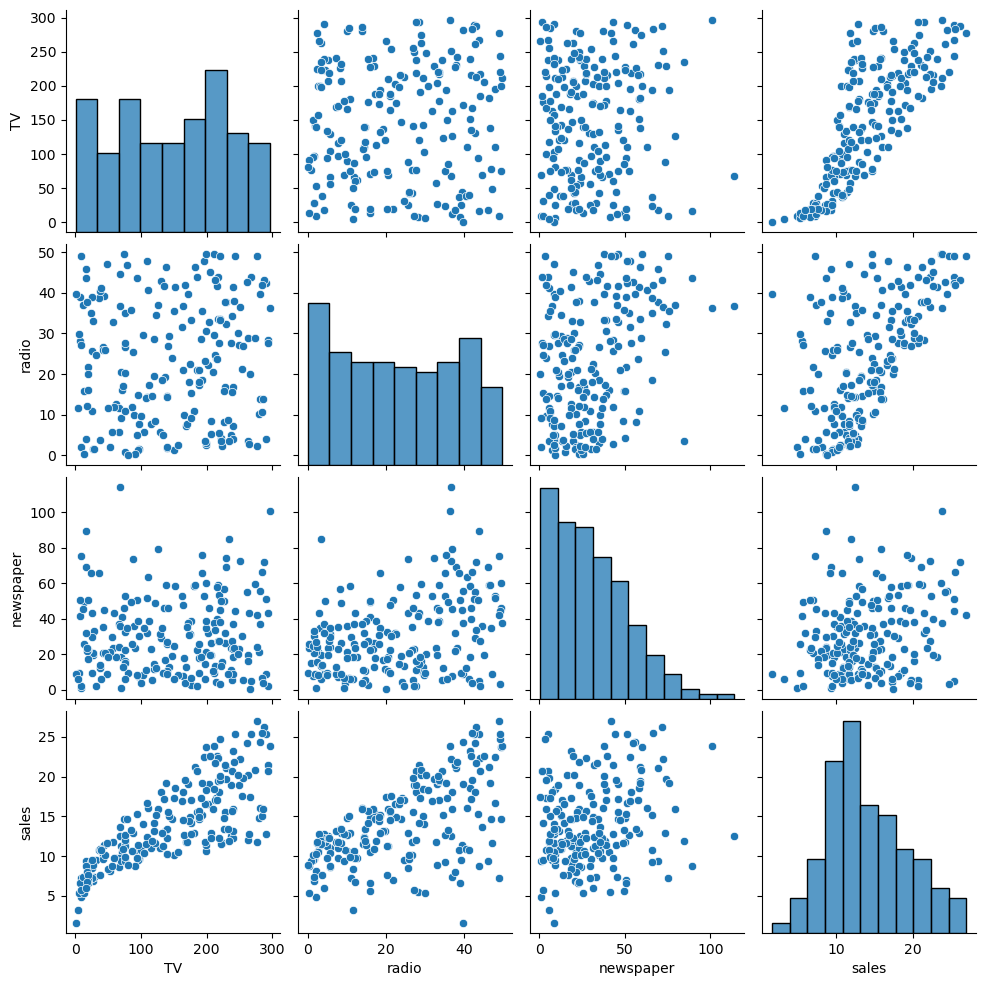

In [58]:
sns.pairplot(data)
plt.show()

In [59]:
X = data[['TV', 'radio', 'newspaper']]
y = data['sales']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

In [62]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(rf, param_grid, cv=3, scoring='r2')
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
rf_pred = best_rf.predict(X_test)

In [63]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n🔹 {name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2 Score:", r2_score(y_true, y_pred))

evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Random Forest (Tuned)", y_test, rf_pred)



🔹 Linear Regression
MAE: 1.4594240185230358
R2 Score: 0.8992146988023269

🔹 Random Forest (Tuned)
MAE: 0.6377463095238085
R2 Score: 0.9810860869011219


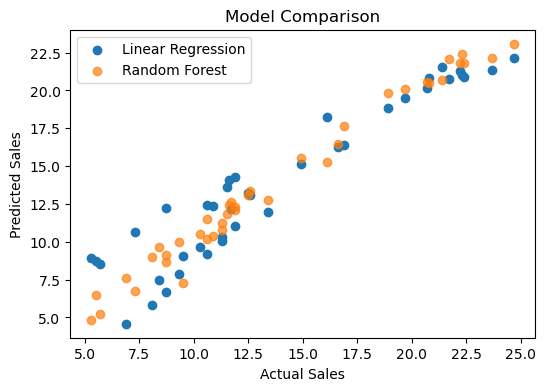

In [64]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, lr_pred, label="Linear Regression")
plt.scatter(y_test, rf_pred, label="Random Forest", alpha=0.7)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Model Comparison")
plt.legend()
plt.show()

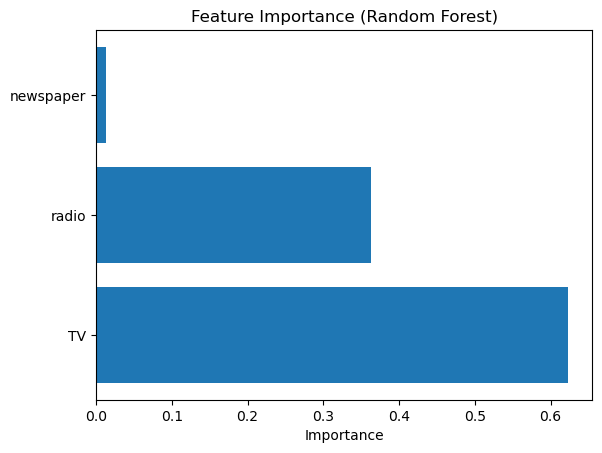


Best RF Parameters: {'max_depth': 10, 'n_estimators': 100}


In [49]:
importances = best_rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

print("\nBest RF Parameters:", grid.best_params_)